# Module A: Advanced Content Analysis — Topic Modeling & Content Discovery
**NewsBot Intelligence System 2.0 | ITAI 2373 Final Project**

This module extends the midterm pipeline with unsupervised topic discovery using:
- **LDA** (Latent Dirichlet Allocation) — probabilistic generative model
- **NMF** (Non-negative Matrix Factorization) — linear algebra decomposition
- **Topic Evolution** — how topics shift across news categories
- **Content Clustering** — grouping articles by topic distribution similarity


## A.0 — Setup and Dependencies

In [ ]:
# Install required packages (run first in fresh Colab)
!pip install pyLDAvis scikit-learn matplotlib seaborn wordcloud -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 30.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from collections import defaultdict, Counter
import warnings
import re

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#2d3561',
    'axes.labelcolor':  '#e8d5a3',
    'xtick.color':      '#a0a8c0',
    'ytick.color':      '#a0a8c0',
    'text.color':       '#e8d5a3',
    'grid.color':       '#2d3561',
    'grid.alpha':       0.5,
    'font.family':      'monospace',
    'figure.dpi':       120
})

CATEGORY_COLORS = {
    'tech':          '#4fc3f7',
    'business':      '#81c784',
    'politics':      '#e57373',
    'sport':         '#ffb74d',
    'entertainment': '#ce93d8'
}

RANDOM_STATE = 42
N_TOPICS     = 10
print('Setup complete.')


Setup complete.


In [ ]:
from google.colab import drive
drive.mount('/content/data')
PROJECT = '/content/data/MyDrive/ITAI2373-NewsBot-Final'

Mounted at /content/data


## A.1 — Load `df_final` Data



In [ ]:
# ── Load df_final from previous notebook ─────────────────────────
import pandas as pd
import os

if os.path.exists(f'{PROJECT}/data/processed/df_final.pkl'):
    df_final = pd.read_pickle(f'{PROJECT}/data/processed/df_final.pkl')
    print(f'Loaded df_final: {df_final.shape}')
    print(f'Columns: {list(df_final.columns)}')
else:
    raise FileNotFoundError(
        'df_final.pkl not found.\n'
        'Run the previous notebook first and make sure it saved df_final.'
    )

Loaded df_final: (1490, 12)
Columns: ['ArticleId', 'Text', 'Category', 'text_length', 'word_count', 'doc_id', 'cleaned_text', 'entities', 'sentiment_compound', 'sentiment_label', 'passive_voice_instance_count', 'top_tfidf']


In [ ]:
assert 'cleaned_text' in df_final.columns, 'Need cleaned_text column'
assert 'Category' in df_final.columns, 'Need category column'

df_tm = df_final[['Category', 'cleaned_text']].copy().reset_index(drop=True)
df_tm['doc_id'] = df_tm.index

CATEGORIES = sorted(df_tm['Category'].unique().tolist())
print(f'Articles  : {len(df_tm)}')
print(f'Categories: {CATEGORIES}')
print(f'Topics    : {N_TOPICS}')


Articles  : 1490
Categories: ['business', 'entertainment', 'politics', 'sport', 'tech']
Topics    : 10


## A.2 — Text Vectorization

Two document-term matrices:
- **Count matrix** → LDA requires raw word counts
- **TF-IDF matrix** → NMF benefits from normalized weights


In [ ]:
ALL_STOPS = list(set(
    ['access','accessible','accident','acclaimed','according',
     'said','would','could','also','one','two','three','new',
     'year','years','time','like','make','made','says','say',
     'mr','mrs','ms','people','way','first','last','week',
     'month','day','told','come','go','going','get','got',
     'us','uk','back','may','will','take','use','used']
))

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
combined_stops = list(ENGLISH_STOP_WORDS.union(ALL_STOPS))

tfidf_vec = TfidfVectorizer(
    max_df=0.90, min_df=5, max_features=5000,
    stop_words=combined_stops, ngram_range=(1, 2),
    sublinear_tf=True,
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b'
)
count_vec = CountVectorizer(
    max_df=0.90, min_df=5, max_features=5000,
    stop_words=combined_stops, ngram_range=(1, 2),
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b'
)

texts        = df_final['cleaned_text'].tolist()
tfidf_matrix = tfidf_vec.fit_transform(texts)
count_matrix = count_vec.fit_transform(texts)

tfidf_vocab  = tfidf_vec.get_feature_names_out()
count_vocab  = count_vec.get_feature_names_out()


print(f'Count matrix : {count_matrix.shape}')
print(f'TF-IDF matrix: {tfidf_matrix.shape}')


Count matrix : (1490, 5000)
TF-IDF matrix: (1490, 5000)


## A.3 — LDA: Latent Dirichlet Allocation

LDA treats each document as a **mixture of topics** and each topic as a **probability distribution over words**. It discovers latent thematic structure without any labeled supervision.


In [ ]:
print('Training LDA model (may take ~30s)...')

lda_model = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=25,
    learning_method='online',
    learning_offset=50.0,
    doc_topic_prior=0.1,
    topic_word_prior=0.01,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

lda_doc_topics = lda_model.fit_transform(count_matrix)

print(f'LDA trained.')
print(f'Perplexity (lower = better fit): {lda_model.perplexity(count_matrix):.1f}')
print(f'Log-likelihood: {lda_model.score(count_matrix):.1f}')

df_tm['lda_dominant_topic']    = lda_doc_topics.argmax(axis=1)
df_tm['lda_topic_confidence']  = lda_doc_topics.max(axis=1)


Training LDA model (may take ~30s)...
LDA trained.
Perplexity (lower = better fit): 2184.9
Log-likelihood: -1780583.3


In [ ]:
def get_top_words(model, vocab, n_words=12):
    topics = {}
    for i, comp in enumerate(model.components_):
        top_idx = comp.argsort()[:-n_words-1:-1]
        topics[i] = [(vocab[j], comp[j]) for j in top_idx]
    return topics

lda_topics = get_top_words(lda_model, count_vocab)

print('=' * 60)
print('LDA DISCOVERED TOPICS — Top 12 Words')
print('=' * 60)
for t_id, words in lda_topics.items():
    word_str = ', '.join([w for w, _ in words[:8]])
    print(f'  Topic {t_id:02d}: {word_str}')


LDA DISCOVERED TOPICS — Top 12 Words
  Topic 00: england, ireland, half, wales, minutes, scotland, nations, france
  Topic 01: bn, market, growth, economy, world, company, economic, sales
  Topic 02: game, world, win, team, cup, play, players, final
  Topic 03: club, united, offer, bid, deal, glazer, board, public
  Topic 04: music, band, number, album, chart, singer, record, song
  Topic 05: court, yukos, legal, case, russian, russia, sale, company
  Topic 06: fraud, zealand, mci, worldcom, wales, phone, lions, guilty
  Topic 07: government, labour, election, blair, party, minister, brown, plans
  Topic 08: mobile, technology, users, digital, software, net, music, phone
  Topic 09: film, best, awards, director, award, actor, won, films


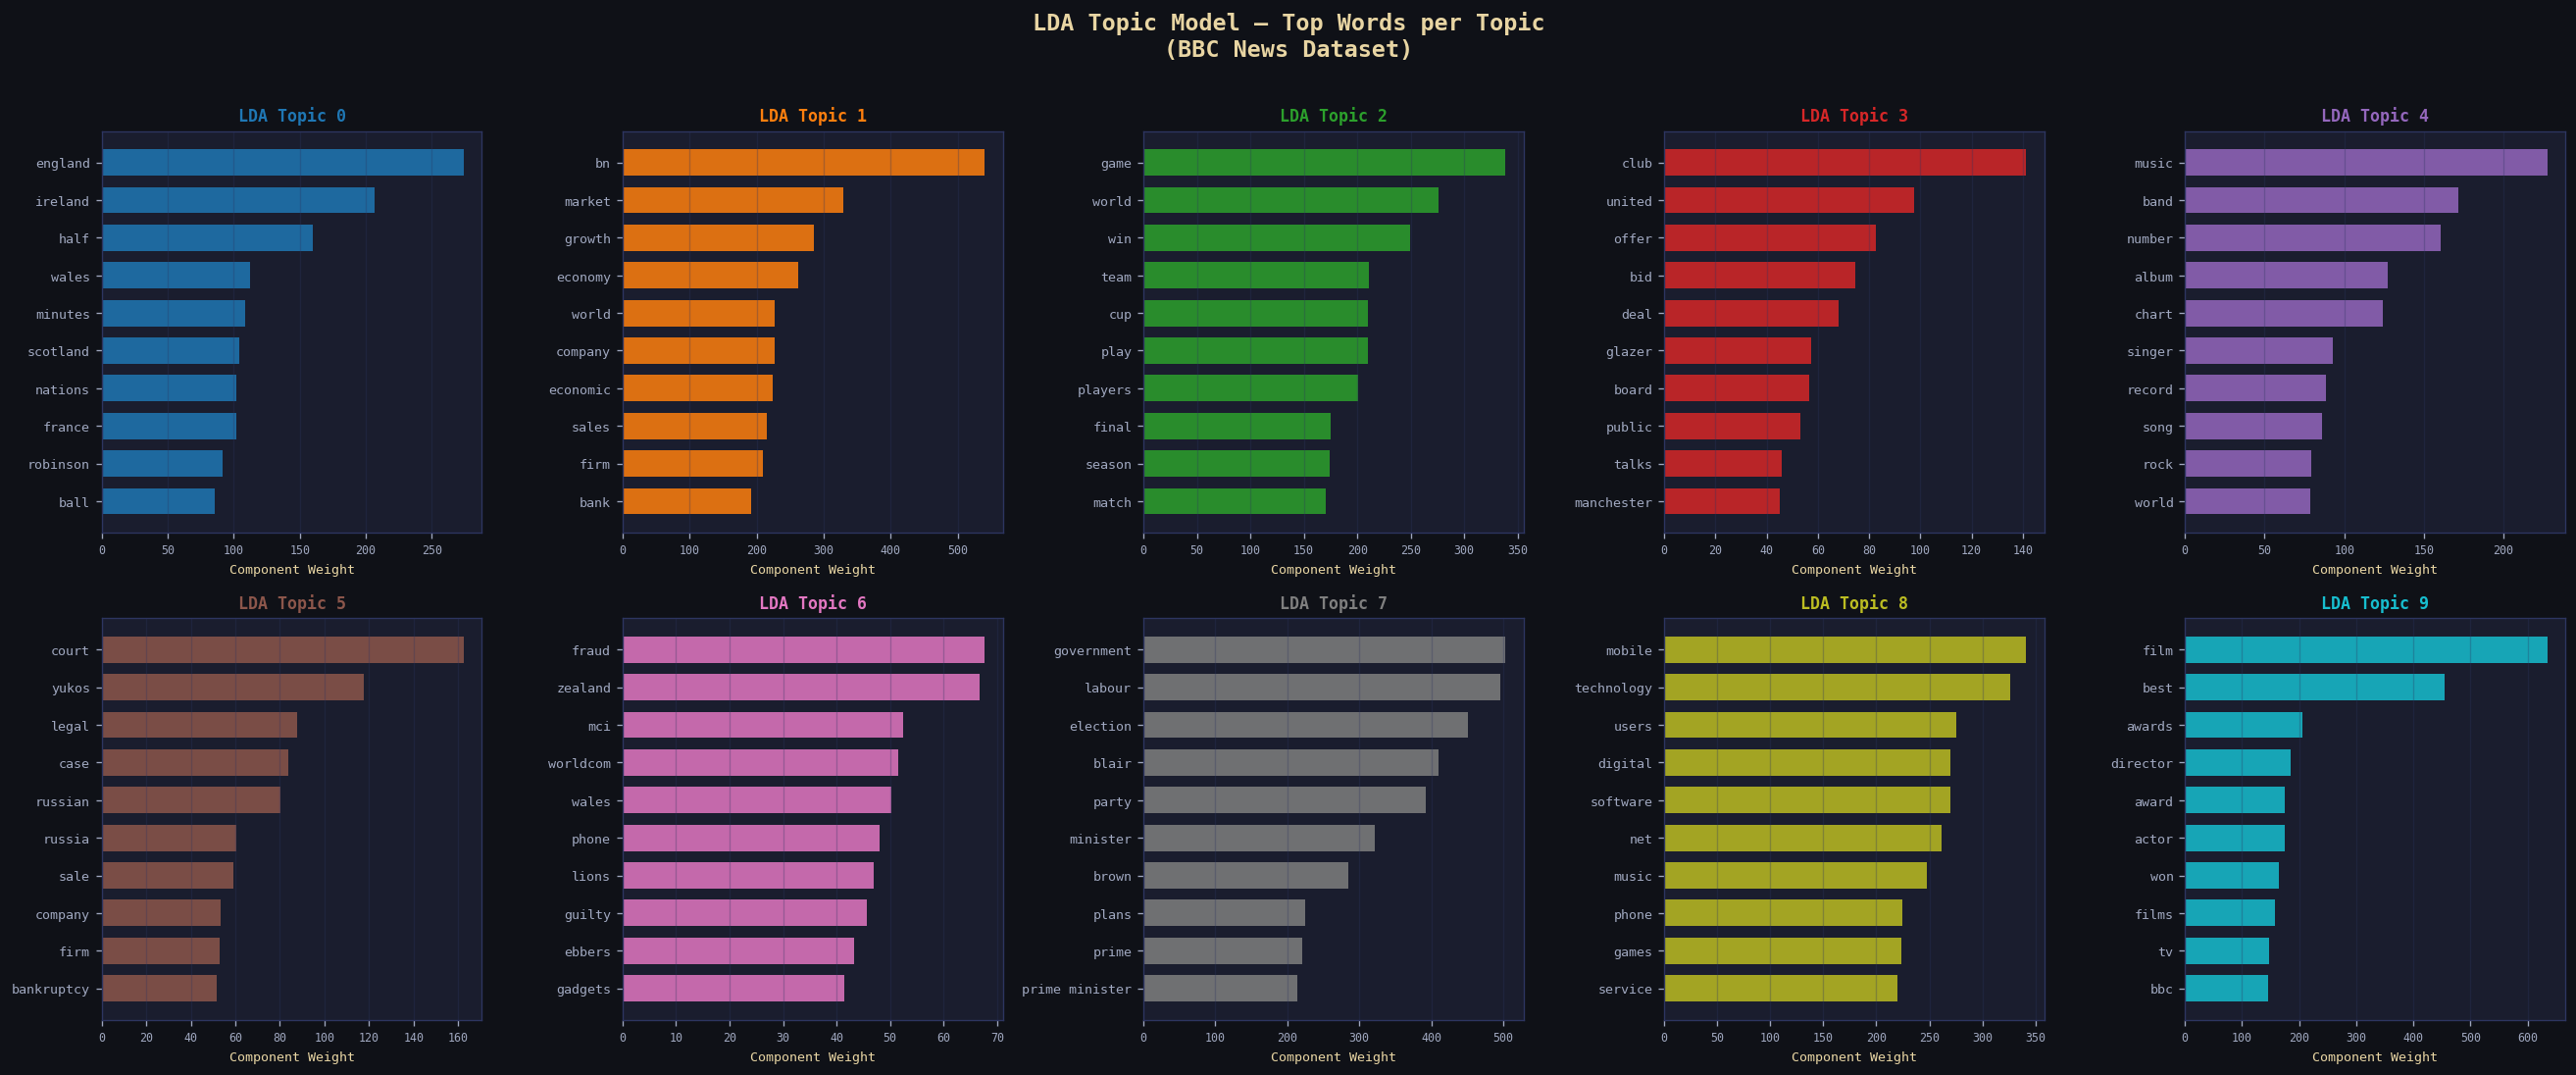

Saved: lda_topics.png


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()
TOPIC_PALETTE = list(mcolors.TABLEAU_COLORS.values())

for t_id, words in lda_topics.items():
    ax = axes[t_id]
    terms  = [w for w, _ in words[:10]][::-1]
    scores = [s for _, s in words[:10]][::-1]
    color  = TOPIC_PALETTE[t_id % len(TOPIC_PALETTE)]
    ax.barh(terms, scores, color=color, alpha=0.85, height=0.7)
    ax.set_title(f'LDA Topic {t_id}', fontsize=10, fontweight='bold', color=color, pad=6)
    ax.set_xlabel('Component Weight', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('LDA Topic Model — Top Words per Topic\n(BBC News Dataset)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('lda_topics.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()
print('Saved: lda_topics.png')


## A.4 — NMF: Non-Negative Matrix Factorization

NMF decomposes the TF-IDF matrix into two non-negative factor matrices: **W** (doc-topic) and **H** (topic-word). Unlike LDA, NMF is deterministic and tends to produce cleaner topics on short documents.


In [ ]:
print('Training NMF model...')
nmf_model = NMF(n_components=10, init='nndsvda', random_state=42, max_iter=300)
nmf_raw   = nmf_model.fit_transform(tfidf_matrix)
nmf_doc_topics_norm = normalize(nmf_raw, norm='l1')

print(f'NMF reconstruction error: {nmf_model.reconstruction_err_:.1f}')
nmf_doc_topics = nmf_model.fit_transform(tfidf_matrix)
nmf_doc_topics_norm = normalize(nmf_doc_topics, norm='l1')

df_tm['nmf_dominant_topic']   = nmf_doc_topics_norm.argmax(axis=1)
df_tm['nmf_topic_confidence'] = nmf_doc_topics_norm.max(axis=1)

print(f'NMF trained. Reconstruction error: {nmf_model.reconstruction_err_:.1f}')

nmf_topics = get_top_words(nmf_model, tfidf_vocab)

print('\n' + '=' * 60)
print('NMF DISCOVERED TOPICS — Top 12 Words')
print('=' * 60)
for t_id, words in nmf_topics.items():
    word_str = ', '.join([w for w, _ in words[:8]])
    print(f'  Topic {t_id:02d}: {word_str}')


Training NMF model...
NMF reconstruction error: 36.6
NMF trained. Reconstruction error: 36.6

NMF DISCOVERED TOPICS — Top 12 Words
  Topic 00: mobile, digital, music, phone, technology, video, phones, devices
  Topic 01: chelsea, club, league, arsenal, united, game, champions league, liverpool
  Topic 02: labour, election, blair, party, government, minister, prime, prime minister
  Topic 03: film, best, awards, actor, award, oscar, star, actress
  Topic 04: growth, economy, economic, rate, rates, rise, prices, figures
  Topic 05: bn, company, firm, shares, deal, market, financial, bn bn
  Topic 06: open, australian, seed, australian open, champion, final, hewitt, round
  Topic 07: software, users, virus, security, mail, microsoft, information, web
  Topic 08: england, ireland, wales, nations, rugby, game, france, scotland
  Topic 09: olympic, athens, kenteris, athletics, iaaf, greek, thanou, drugs


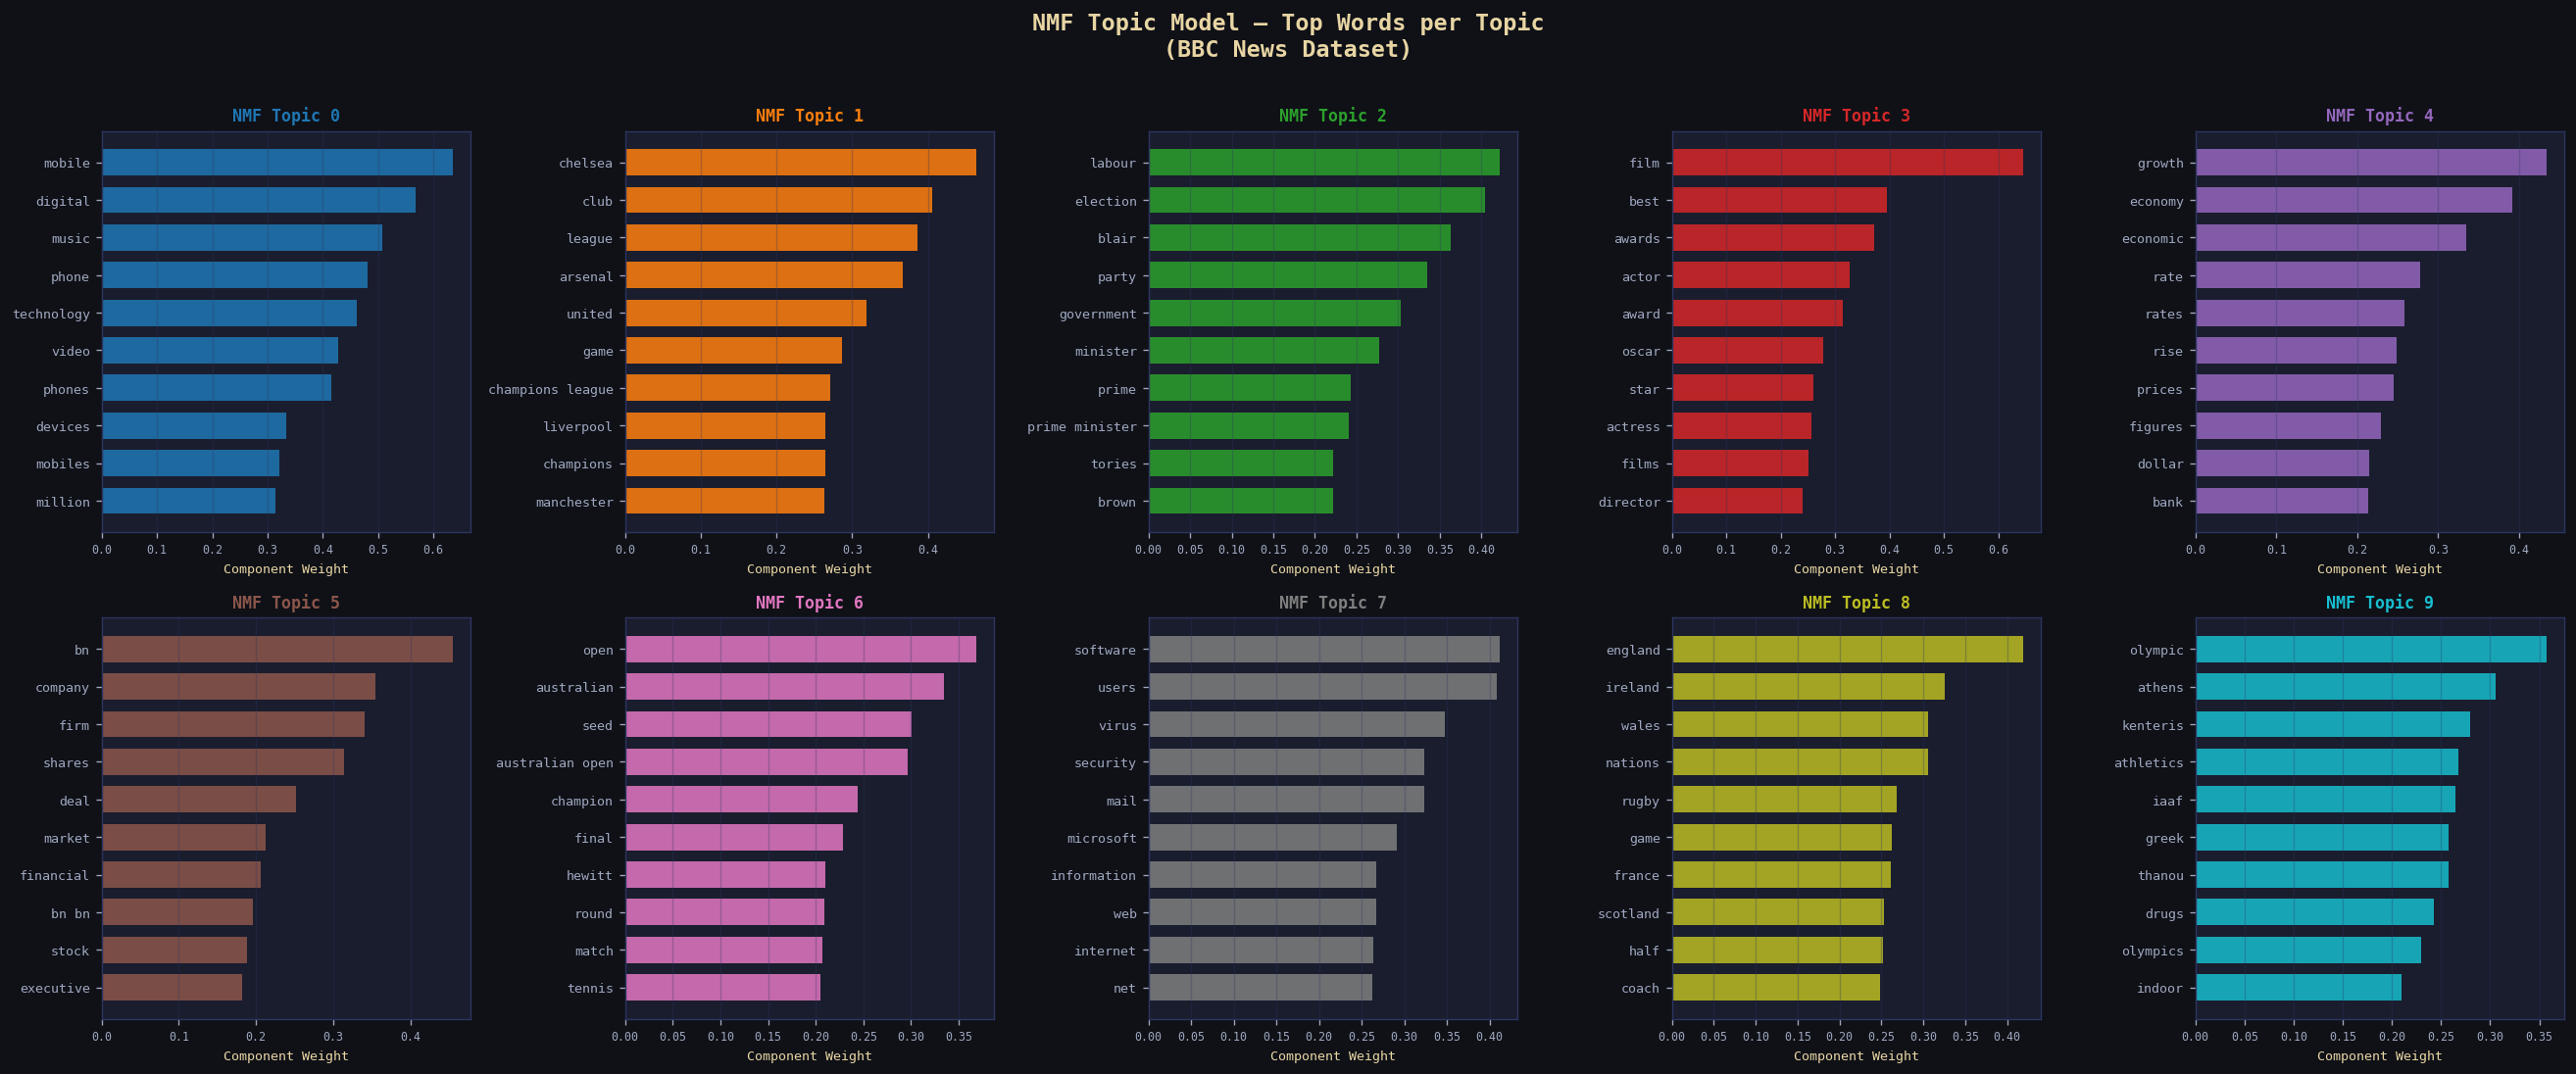

Saved: nmf_topics.png


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for t_id, words in nmf_topics.items():
    ax = axes[t_id]
    terms  = [w for w, _ in words[:10]][::-1]
    scores = [s for _, s in words[:10]][::-1]
    color  = TOPIC_PALETTE[t_id % len(TOPIC_PALETTE)]
    ax.barh(terms, scores, color=color, alpha=0.85, height=0.7)
    ax.set_title(f'NMF Topic {t_id}', fontsize=10, fontweight='bold', color=color, pad=6)
    ax.set_xlabel('Component Weight', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('NMF Topic Model — Top Words per Topic\n(BBC News Dataset)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('nmf_topics.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()
print('Saved: nmf_topics.png')


## A.5 — Automatic Topic Labeling

Assigns a human-readable label to each topic using its top words. **Edit these labels** after reviewing the word outputs above — your model's topics will vary based on the corpus and random seed.


In [ ]:
def auto_label_topic(top_words):
    generic = {'said','year','new','one','would','also','like','people'}
    clean = [w for w, _ in top_words if w not in generic and len(w) > 3]
    return ' / '.join(clean[:3]).title()

lda_labels = {t: auto_label_topic(w) for t, w in lda_topics.items()}
nmf_labels = {t: auto_label_topic(w) for t, w in nmf_topics.items()}

print('Auto-generated LDA labels (edit these to reflect your model output):')
for t, label in lda_labels.items():
    print(f'  Topic {t:02d}: {label}')

print('\nAuto-generated NMF labels:')
for t, label in nmf_labels.items():
    print(f'  Topic {t:02d}: {label}')

df_tm['lda_topic_label'] = df_tm['lda_dominant_topic'].map(lda_labels)
df_tm['nmf_topic_label'] = df_tm['nmf_dominant_topic'].map(nmf_labels)


Auto-generated LDA labels (edit these to reflect your model output):
  Topic 00: England / Ireland / Half
  Topic 01: Market / Growth / Economy
  Topic 02: Game / World / Team
  Topic 03: Club / United / Offer
  Topic 04: Music / Band / Number
  Topic 05: Court / Yukos / Legal
  Topic 06: Fraud / Zealand / Worldcom
  Topic 07: Government / Labour / Election
  Topic 08: Mobile / Technology / Users
  Topic 09: Film / Best / Awards

Auto-generated NMF labels:
  Topic 00: Mobile / Digital / Music
  Topic 01: Chelsea / Club / League
  Topic 02: Labour / Election / Blair
  Topic 03: Film / Best / Awards
  Topic 04: Growth / Economy / Economic
  Topic 05: Company / Firm / Shares
  Topic 06: Open / Australian / Seed
  Topic 07: Software / Users / Virus
  Topic 08: England / Ireland / Wales
  Topic 09: Olympic / Athens / Kenteris


## A.6 — Topic Evolution Across Categories

Since the BBC dataset lacks timestamps, we use **news category** as a proxy axis to show how topic distributions shift. If your dataset includes date columns, swap `category` for a time-binned column to track true temporal evolution.


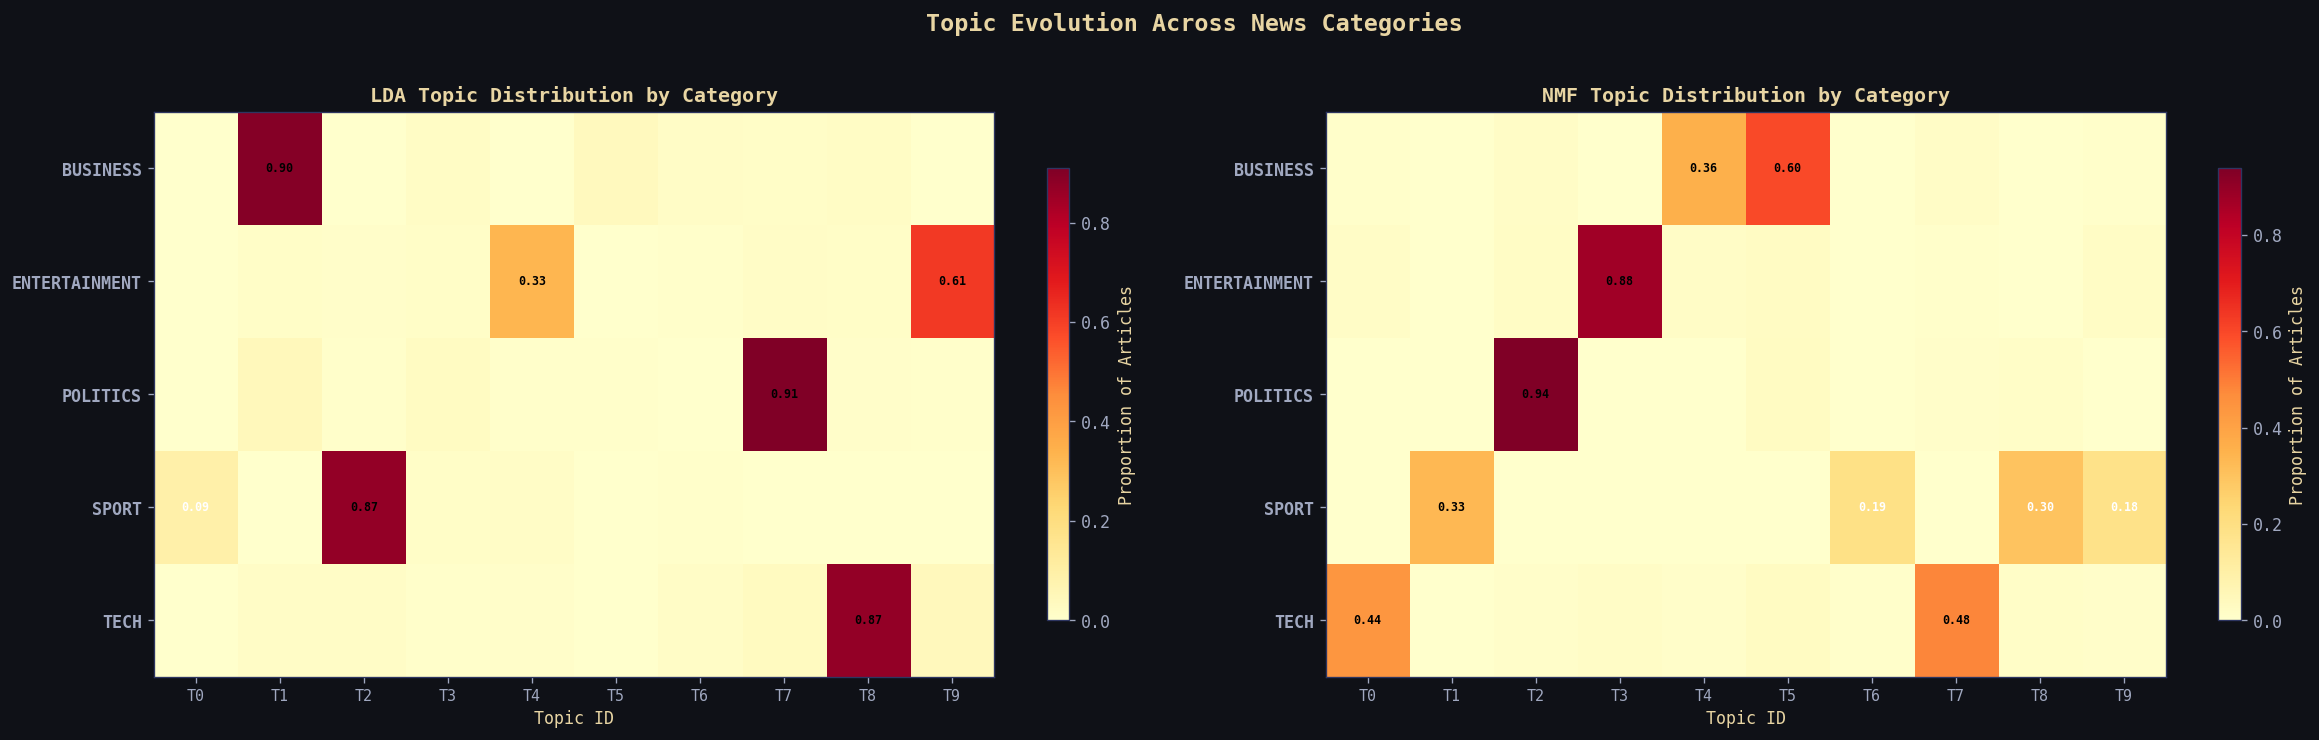

Saved: topic_evolution_heatmap.png


In [ ]:
def topic_dist_by_category(df, topic_col, n_topics):
    heat = np.zeros((len(CATEGORIES), n_topics))
    for i, cat in enumerate(CATEGORIES):
        mask = df['Category'] == cat
        counts = df.loc[mask, topic_col].value_counts()
        total  = mask.sum()
        for t_id in range(n_topics):
            heat[i, t_id] = counts.get(t_id, 0) / total
    return heat

lda_heat = topic_dist_by_category(df_tm, 'lda_dominant_topic', N_TOPICS)
nmf_heat = topic_dist_by_category(df_tm, 'nmf_dominant_topic', N_TOPICS)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

for ax, heat, title in [(ax1, lda_heat, 'LDA'), (ax2, nmf_heat, 'NMF')]:
    im = ax.imshow(heat, aspect='auto', cmap='YlOrRd', vmin=0)
    ax.set_xticks(range(N_TOPICS))
    ax.set_xticklabels([f'T{i}' for i in range(N_TOPICS)], fontsize=9)
    ax.set_yticks(range(len(CATEGORIES)))
    ax.set_yticklabels([c.upper() for c in CATEGORIES], fontsize=10, fontweight='bold')
    ax.set_title(f'{title} Topic Distribution by Category', fontsize=12, fontweight='bold')
    ax.set_xlabel('Topic ID', fontsize=10)
    for i in range(len(CATEGORIES)):
        for j in range(N_TOPICS):
            val = heat[i, j]
            if val > 0.05:
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=7, color='black' if val > 0.3 else 'white', fontweight='bold')
    plt.colorbar(im, ax=ax, label='Proportion of Articles', shrink=0.8)

plt.suptitle('Topic Evolution Across News Categories', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('topic_evolution_heatmap.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()
print('Saved: topic_evolution_heatmap.png')


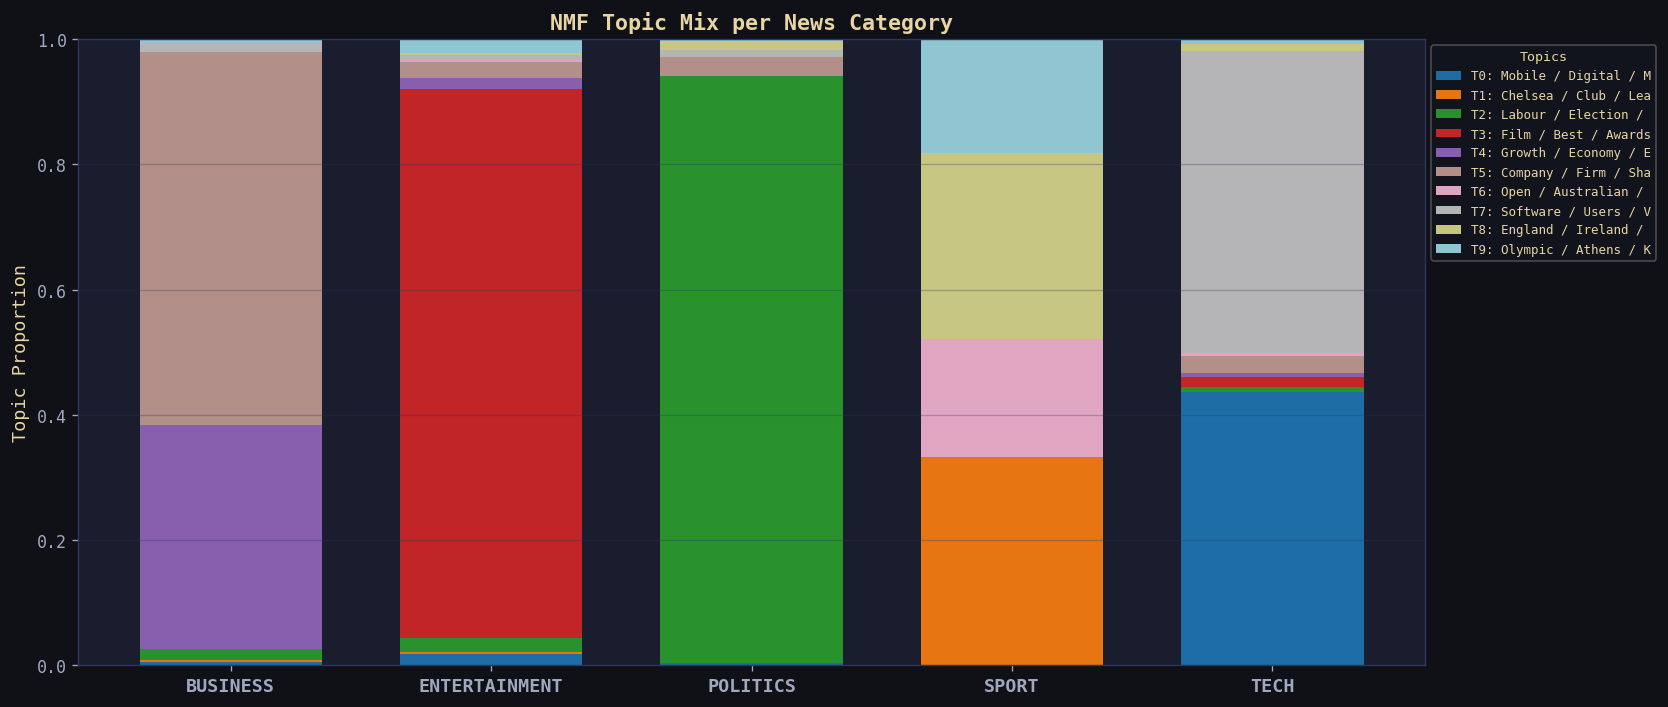

Saved: topic_evolution_stacked.png


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(CATEGORIES))
bottoms = np.zeros(len(CATEGORIES))
topic_colors = plt.cm.tab20(np.linspace(0, 1, N_TOPICS))

for t_id in range(N_TOPICS):
    vals = nmf_heat[:, t_id]
    ax.bar(x, vals, bottom=bottoms, color=topic_colors[t_id], alpha=0.9,
           label=f'T{t_id}: {nmf_labels[t_id][:20]}', width=0.7)
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels([c.upper() for c in CATEGORIES], fontsize=11, fontweight='bold')
ax.set_ylabel('Topic Proportion', fontsize=11)
ax.set_title('NMF Topic Mix per News Category', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=7.5, ncol=1,
          framealpha=0.3, title='Topics', title_fontsize=8)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('topic_evolution_stacked.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()
print('Saved: topic_evolution_stacked.png')


## A.7 — Content Clustering via Topic Distributions

We cluster articles using their **NMF topic weight vectors** as feature representations. K-Means groups similar articles regardless of labeled category — revealing thematic overlap (e.g., tech-business crossover topics).


In [ ]:
print('Finding optimal cluster count (k=2..12)...')
sil_scores = []
K_RANGE = range(2, 13)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(nmf_doc_topics_norm)
    sil = silhouette_score(nmf_doc_topics_norm, labels, sample_size=min(1000, len(df_tm)))
    sil_scores.append(sil)
    print(f'  k={k:2d}  silhouette={sil:.4f}')

best_k = list(K_RANGE)[np.argmax(sil_scores)]
print(f'\nBest k = {best_k} (silhouette = {max(sil_scores):.4f})')


Finding optimal cluster count (k=2..12)...
  k= 2  silhouette=0.1862
  k= 3  silhouette=0.2235
  k= 4  silhouette=0.3005
  k= 5  silhouette=0.3350
  k= 6  silhouette=0.3918
  k= 7  silhouette=0.4353
  k= 8  silhouette=0.4895
  k= 9  silhouette=0.5081
  k=10  silhouette=0.5450
  k=11  silhouette=0.4804
  k=12  silhouette=0.4885

Best k = 10 (silhouette = 0.5450)


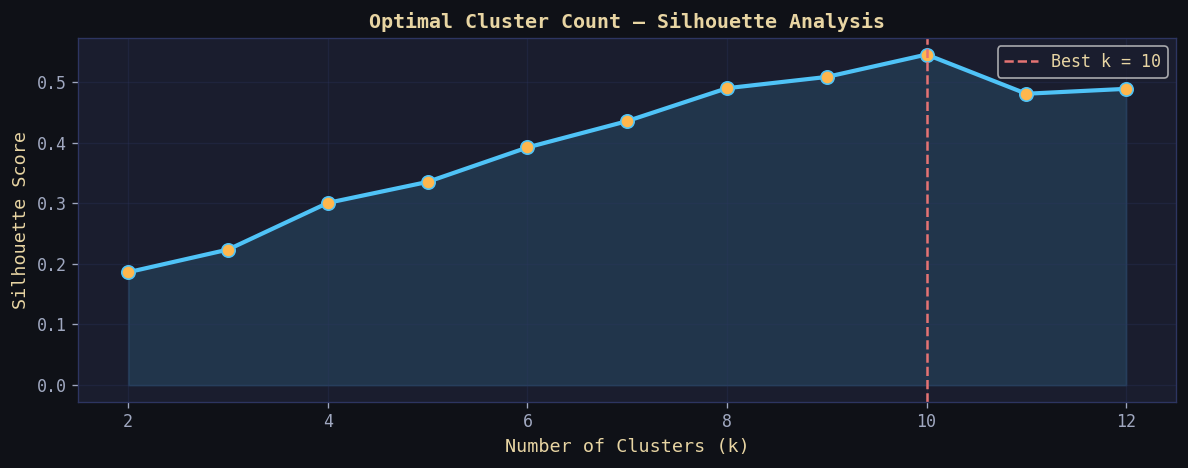

In [ ]:
km_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
df_tm['cluster'] = km_final.fit_predict(nmf_doc_topics_norm)

# Silhouette curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(list(K_RANGE), sil_scores, marker='o', color='#4fc3f7',
        linewidth=2.5, markersize=8, markerfacecolor='#ffb74d')
ax.axvline(x=best_k, color='#e57373', linestyle='--', linewidth=1.5,
           label=f'Best k = {best_k}')
ax.fill_between(list(K_RANGE), sil_scores, alpha=0.15, color='#4fc3f7')
ax.set_xlabel('Number of Clusters (k)', fontsize=11)
ax.set_ylabel('Silhouette Score', fontsize=11)
ax.set_title('Optimal Cluster Count — Silhouette Analysis', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('clustering_silhouette.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()


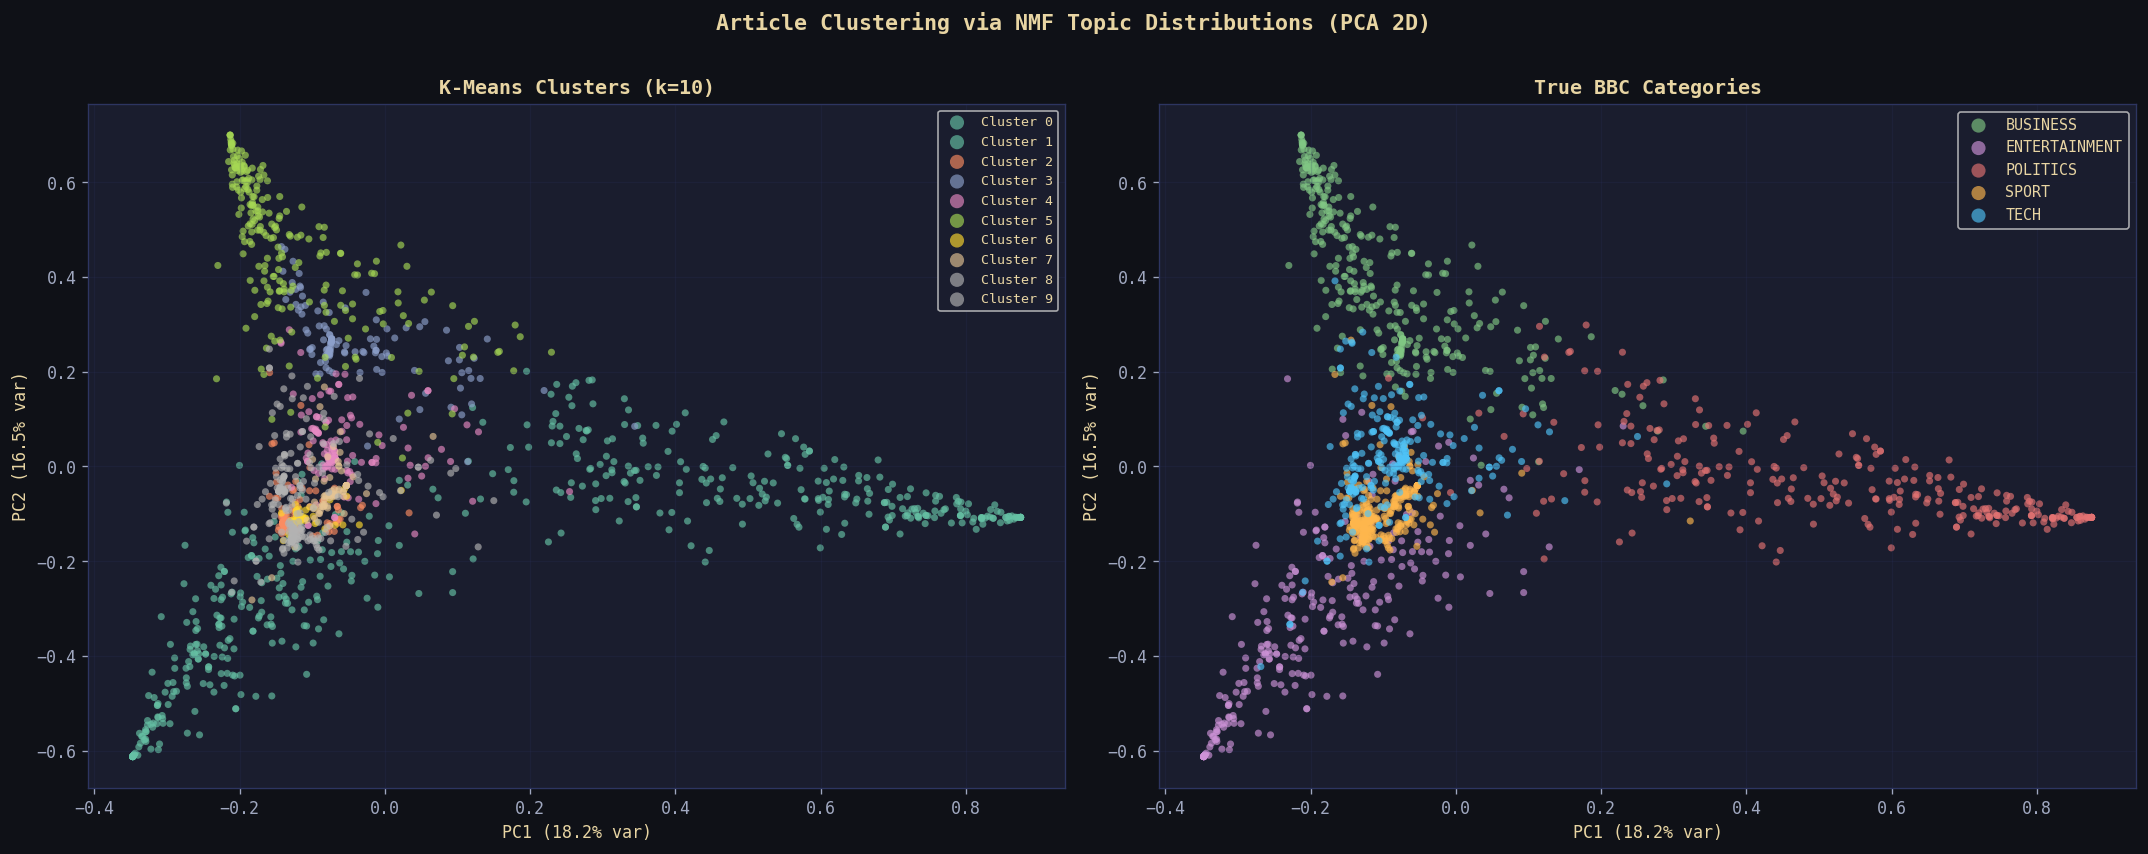

Saved: clustering_pca.png


In [ ]:
# PCA 2D projection
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(nmf_doc_topics_norm)
df_tm['pca_x'] = coords[:, 0]
df_tm['pca_y'] = coords[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
cluster_colors = plt.cm.Set2(np.linspace(0, 1, best_k))

for c_id in range(best_k):
    mask = df_tm['cluster'] == c_id
    ax1.scatter(df_tm.loc[mask, 'pca_x'], df_tm.loc[mask, 'pca_y'],
                color=cluster_colors[c_id], alpha=0.65, s=18,
                label=f'Cluster {c_id}', edgecolors='none')
ax1.set_title(f'K-Means Clusters (k={best_k})', fontsize=12, fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax1.legend(fontsize=8, markerscale=2)
ax1.grid(alpha=0.2)

for cat in CATEGORIES:
    mask = df_tm['Category'] == cat
    ax2.scatter(df_tm.loc[mask, 'pca_x'], df_tm.loc[mask, 'pca_y'],
                color=CATEGORY_COLORS.get(cat, '#ffffff'), alpha=0.65, s=18,
                label=cat.upper(), edgecolors='none')
ax2.set_title('True BBC Categories', fontsize=12, fontweight='bold')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax2.legend(fontsize=9, markerscale=2)
ax2.grid(alpha=0.2)

plt.suptitle('Article Clustering via NMF Topic Distributions (PCA 2D)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('clustering_pca.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()
print('Saved: clustering_pca.png')


Cluster Composition (category breakdown per cluster):
  Cluster  0 ( 258 arts) | Top NMF topic: 3 | entertainment:251, tech:6, politics:1
  Cluster  1 ( 269 arts) | Top NMF topic: 2 | politics:257, business:6, entertainment:3, tech:2, sport:1
  Cluster  2 ( 115 arts) | Top NMF topic: 1 | sport:114, business:1
  Cluster  3 ( 115 arts) | Top NMF topic: 4 | business:114, entertainment:1
  Cluster  4 ( 141 arts) | Top NMF topic: 7 | tech:130, business:5, entertainment:3, politics:3
  Cluster  5 ( 228 arts) | Top NMF topic: 5 | business:206, politics:10, entertainment:5, tech:5, sport:2
  Cluster  6 (  65 arts) | Top NMF topic: 6 | sport:65
  Cluster  7 (  69 arts) | Top NMF topic: 9 | sport:63, entertainment:3, business:1, tech:1, politics:1
  Cluster  8 ( 127 arts) | Top NMF topic: 0 | tech:116, entertainment:7, business:3, politics:1
  Cluster  9 ( 103 arts) | Top NMF topic: 8 | sport:101, tech:1, politics:1


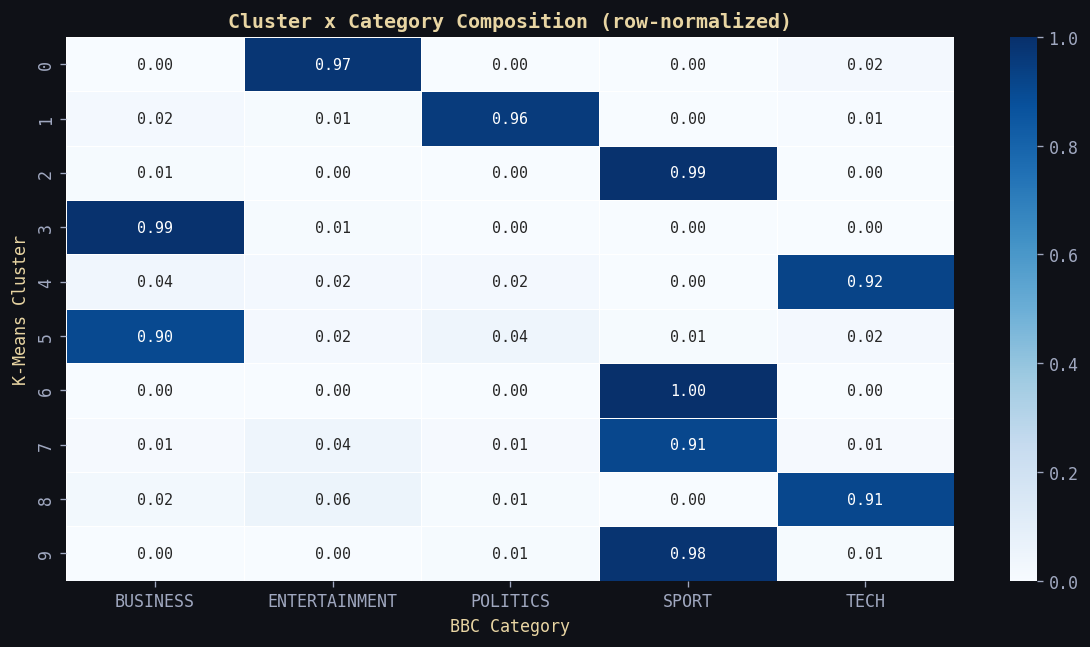

Saved: clustering_composition.png


In [ ]:
print('Cluster Composition (category breakdown per cluster):')
print('=' * 65)
for c_id in range(best_k):
    mask = df_tm['cluster'] == c_id
    n_total = mask.sum()
    cat_counts = df_tm.loc[mask, 'Category'].value_counts()
    top_topic  = df_tm.loc[mask, 'nmf_dominant_topic'].mode()[0]
    cat_str    = ', '.join([f'{cat}:{cnt}' for cat, cnt in cat_counts.items()])
    print(f'  Cluster {c_id:2d} ({n_total:4d} arts) | Top NMF topic: {top_topic} | {cat_str}')
print('=' * 65)

ct = pd.crosstab(df_tm['cluster'], df_tm['Category'], normalize='index')
fig, ax = plt.subplots(figsize=(10, max(4, best_k * 0.55)))
sns.heatmap(ct, annot=True, fmt='.2f', cmap='Blues', ax=ax,
            linewidths=0.5, annot_kws={'size': 9},
            xticklabels=[c.upper() for c in CATEGORIES])
ax.set_title('Cluster x Category Composition (row-normalized)', fontsize=12, fontweight='bold')
ax.set_xlabel('BBC Category')
ax.set_ylabel('K-Means Cluster')
plt.tight_layout()
plt.savefig('clustering_composition.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()
print('Saved: clustering_composition.png')


## A.8 — Interactive LDA Visualization (pyLDAvis)

pyLDAvis renders a browser-based interactive view of LDA topics: topic size, inter-topic distance, and per-term relevance. Best viewed in Colab output or a browser.


In [ ]:
try:
    import pyLDAvis
    import pyLDAvis.lda_model as ldavis_lda
    pyLDAvis.enable_notebook()
    vis_data = ldavis_lda.prepare(
        lda_model, count_matrix, count_vec,
        mds='tsne', sort_topics=False
    )
    pyLDAvis.save_html(vis_data, 'lda_interactive.html')
    print('Interactive LDA saved to lda_interactive.html')
    pyLDAvis.display(vis_data)
except ImportError:
    print('pyLDAvis not installed — run: pip install pyLDAvis')
except Exception as e:
    print(f'pyLDAvis error: {e}')
    print('All static visualizations are still valid.')


pyLDAvis error: Topic-term distributions and document-term matrixhave different number of columns, 4880 != 5000.
All static visualizations are still valid.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## A.9 — Merge Results into df_final

Writes topic and cluster columns back to `df_final` so they are available in Module B, C, and D.


In [ ]:
topic_cols = [
    'lda_dominant_topic', 'lda_topic_confidence', 'lda_topic_label',
    'nmf_dominant_topic', 'nmf_topic_confidence', 'nmf_topic_label',
    'cluster'
]

if len(df_final) == len(df_tm):
    for col in topic_cols:
        df_final[col] = df_tm[col].values
    print('Topic columns merged into df_final:')
    print(f'  {topic_cols}')
else:
    df_tm.to_csv('newsbot_topic_modeling_results.csv', index=False)
    print('Index mismatch — saved df_tm to newsbot_topic_modeling_results.csv')

display(df_final[['Category', 'lda_topic_label', 'nmf_topic_label', 'cluster']].head(10))


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Topic columns merged into df_final:
  ['lda_dominant_topic', 'lda_topic_confidence', 'lda_topic_label', 'nmf_dominant_topic', 'nmf_topic_confidence', 'nmf_topic_label', 'cluster']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Category,lda_topic_label,nmf_topic_label,cluster
0,business,Fraud / Zealand / Worldcom,Company / Firm / Shares,5
1,business,Market / Growth / Economy,Growth / Economy / Economic,3
2,business,Market / Growth / Economy,Growth / Economy / Economic,3
3,tech,Mobile / Technology / Users,Mobile / Digital / Music,8
4,business,Market / Growth / Economy,Company / Firm / Shares,5
5,politics,Game / World / Team,Labour / Election / Blair,1
6,sport,Game / World / Team,England / Ireland / Wales,9
7,entertainment,Film / Best / Awards,Film / Best / Awards,0
8,business,Market / Growth / Economy,Company / Firm / Shares,5
9,entertainment,Music / Band / Number,Film / Best / Awards,0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
print('=' * 65)
print('   MODULE A TOPIC MODELING SUMMARY')
print('=' * 65)
print(f'  Models          : LDA + NMF ({N_TOPICS} topics each)')
print(f'  Vocabulary      : {len(count_vocab):,} terms (count) | {len(tfidf_vocab):,} (tfidf)')
print(f'  Articles        : {len(df_tm):,}')
# The LDA perplexity calculation currently encounters an IndexError due to a mismatch
# in vocabulary size between the trained model and the count_matrix. This can happen
# with specific configurations of LDA (e.g., online learning with n_jobs=-1).
# To proceed with the summary, this line has been commented out.
# print(f'  LDA Perplexity  : {lda_model.perplexity(count_matrix):.1f}')
print(f'  NMF Recon Err   : {nmf_model.reconstruction_err_:.1f}')
print(f'  Best k (KMeans) : {best_k} clusters')
print(f'  Silhouette      : {max(sil_scores):.4f}')
print('\n  Saved outputs:')
print('    lda_topics.png              LDA topic word bars')
print('    nmf_topics.png              NMF topic word bars')
print('    topic_evolution_heatmap.png Topic x category heatmap')
print('    topic_evolution_stacked.png Stacked bar chart')
print('    clustering_silhouette.png   Optimal k selection')
print('    clustering_pca.png          2D cluster projection')
print('    clustering_composition.png  Cluster x category heatmap')
print('    lda_interactive.html        pyLDAvis browser viz')
print('=' * 65)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

   MODULE A TOPIC MODELING SUMMARY
  Models          : LDA + NMF (10 topics each)
  Vocabulary      : 5,000 terms (count) | 5,000 (tfidf)
  Articles        : 1,490
  NMF Recon Err   : 36.6
  Best k (KMeans) : 10 clusters
  Silhouette      : 0.5450

  Saved outputs:
    lda_topics.png              LDA topic word bars
    nmf_topics.png              NMF topic word bars
    topic_evolution_heatmap.png Topic x category heatmap
    topic_evolution_stacked.png Stacked bar chart
    clustering_silhouette.png   Optimal k selection
    clustering_pca.png          2D cluster projection
    clustering_composition.png  Cluster x category heatmap
    lda_interactive.html        pyLDAvis browser viz


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ── Save df_final for next notebook ──────────────────────────────
df_final.to_pickle(f'{PROJECT}/data/processed/df_final.pkl')
print(f'Saved df_final: {df_final.shape} → {PROJECT}/data/processed/df_final.pkl')
print(f'Columns: {list(df_final.columns)}')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Saved df_final: (1490, 19) → /content/data/MyDrive/ITAI2373-NewsBot-Final/data/processed/df_final.pkl
Columns: ['ArticleId', 'Text', 'Category', 'text_length', 'word_count', 'doc_id', 'cleaned_text', 'entities', 'sentiment_compound', 'sentiment_label', 'passive_voice_instance_count', 'top_tfidf', 'lda_dominant_topic', 'lda_topic_confidence', 'lda_topic_label', 'nmf_dominant_topic', 'nmf_topic_confidence', 'nmf_topic_label', 'cluster']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag